<a href="https://colab.research.google.com/github/naufal11705/PCVK_Genap_2021/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Gamma Correction pada citra
----------------------------------
Masukkan nilai Gamma: 3


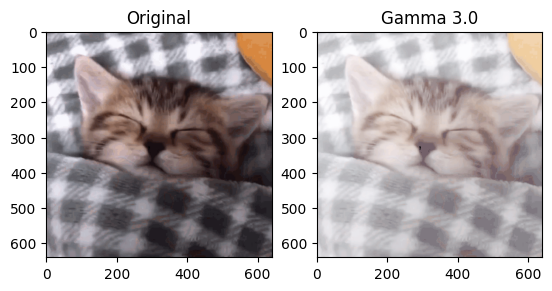

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

print('Gamma Correction pada citra')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, bukan angka')
    exit()

# Ambil gambar dari URL
url = 'https://media.tenor.com/tIPDs-HGMHkAAAAe/cat-catto.png'
resp = urllib.request.urlopen(url)
image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
img = cv.imdecode(image_array, cv.IMREAD_COLOR)  # <-- tetap berwarna (BGR)

# Ubah dari BGR ke RGB agar tampil benar di matplotlib
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Normalisasi dan transformasi gamma
normalized = img_rgb / 255.0
gamma_corrected = np.power(normalized, 1/gamma)
output = np.uint8(gamma_corrected * 255)

# Tampilkan hasil
plt.subplot(1, 2, 1), plt.imshow(img_rgb), plt.title('Original')
plt.subplot(1, 2, 2), plt.imshow(output), plt.title(f'Gamma {gamma}')
plt.show()

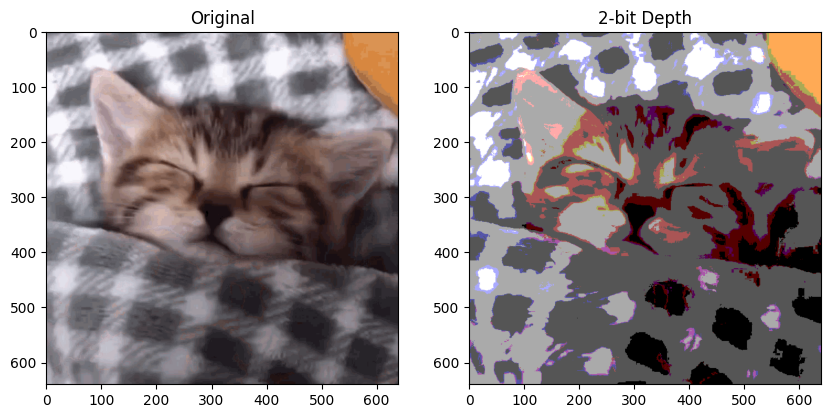

In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# Ambil gambar dari URL
url = 'https://media.tenor.com/tIPDs-HGMHkAAAAe/cat-catto.png'
resp = urllib.request.urlopen(url)
image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
img = cv.imdecode(image_array, cv.IMREAD_COLOR)  # tetap berwarna (BGR)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)     # ubah ke RGB untuk matplotlib

# Parameter bit depth
bit_depth = 2
level = 255 / (pow(2, bit_depth) - 1)

# Terapkan bit depth reduction ke setiap kanal warna
depth_image = np.round((img_rgb / level)) * level
depth_image = np.uint8(depth_image)

# Tampilkan hasil
plt.figure(figsize=(10,5))
plt.subplot(1,2,1), plt.imshow(img_rgb), plt.title('Original')
plt.subplot(1,2,2), plt.imshow(depth_image), plt.title(f'{bit_depth}-bit Depth')
plt.show()

Jumlah citra: 5, PSNR: 29.97 dB
Jumlah citra: 10, PSNR: 31.28 dB
Jumlah citra: 20, PSNR: 33.24 dB
Jumlah citra: 40, PSNR: 35.71 dB
Jumlah citra: 80, PSNR: 38.10 dB
Jumlah citra: 100, PSNR: 38.80 dB


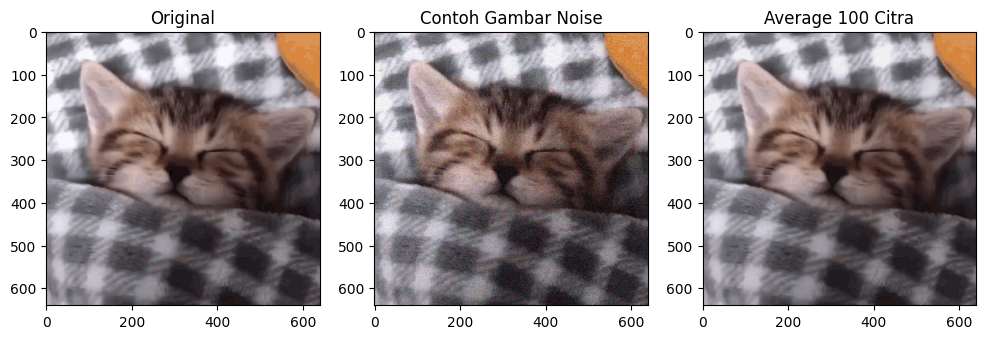

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from math import log10, sqrt

# --- Fungsi PSNR ---
def PSNR(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr

# --- Ambil gambar dari URL (gambar kucing) ---
url = 'https://media.tenor.com/tIPDs-HGMHkAAAAe/cat-catto.png'
resp = urllib.request.urlopen(url)
image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
original = cv.imdecode(image_array, cv.IMREAD_COLOR)
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# --- Buat kumpulan gambar dengan noise Gaussian ---
num_noisy_images = 100
cv_img = []
for i in range(num_noisy_images):
    noise = np.random.normal(0, 25, original.shape).astype(np.float32)  # sigma=25
    noisy = np.clip(original.astype(np.float32) + noise, 0, 255)
    cv_img.append(noisy.astype(np.uint8))

# --- Average denoising untuk berbagai jumlah citra ---
jumlah_list = [5, 10, 20, 40, 80, 100]
psnr_values = []

for jumlah in jumlah_list:
    avg_img = np.zeros_like(cv_img[0], dtype=np.float32)
    for i in range(jumlah):
        avg_img += cv_img[i].astype(np.float32)
    avg_img /= jumlah
    avg_img = np.uint8(avg_img)
    psnr = PSNR(original, avg_img)
    psnr_values.append(psnr)

# --- Tampilkan hasil PSNR ---
for i, jumlah in enumerate(jumlah_list):
    print(f'Jumlah citra: {jumlah}, PSNR: {psnr_values[i]:.2f} dB')

# --- Visualisasi hasil ---
plt.figure(figsize=(12,6))
plt.subplot(1,3,1), plt.imshow(original), plt.title('Original')
plt.subplot(1,3,2), plt.imshow(cv_img[0]), plt.title('Contoh Gambar Noise')
plt.subplot(1,3,3), plt.imshow(np.uint8(avg_img)), plt.title(f'Average {jumlah_list[-1]} Citra')
plt.show()